In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.stats import ks_2samp

from utilsPlots import *


In [2]:
datadir = Path('../../datadir')

figdir = Path('./figs')
figdir.mkdir(exist_ok=True, parents=True)


In [3]:
df_all = pd.read_csv('df_all.csv')
df_all = df_all.drop_duplicates(subset='ID', keep='first')


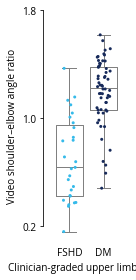

p = 3.358585494487827e-08


In [4]:
types = ['FSHD', 'DM']
colors = [cp[3], cp[0]]
feat = 'brooke_max_sa_ea_ratio'

df = df_all[df_all.brooke_score >= 4].copy()
df['brooke_group'] = df.brooke_score.apply(lambda x : f'{int(x)}')

plt.figure(figsize=(2,4))
sns.boxplot(df, x='type', y=feat, hue='type', order=types,
            hue_order=types, linewidth=1, whis=[0, 100],
            palette=['#808080']*len(types), saturation=1, fill=None,  legend=False)
np.random.seed(0)
sns.stripplot(df, x='type', y=feat, order=types, size=3, jitter=0.2,
              hue='type', hue_order=types, palette=colors)
plt.yticks([0.2, 1.0, 1.8])
plt.ylim(0.1, 1.8)
sns.despine(trim=True)
sns.despine(bottom=True, trim=False)
plt.gca().tick_params(bottom=False)
plt.ylabel('Video shoulder–elbow angle ratio')
plt.xlabel('Clinician-graded upper limb score')

plt.gca().margins(0.2, 0.2)
plt.tight_layout()
plt.savefig(figdir/'fig3b_brooke_fshd_dm.pdf')
plt.show()

result = ks_2samp(
    df[df.type==types[0]][feat],
    df[df.type==types[1]][feat],
    alternative='two-sided',
)
pval = result.pvalue
print('p =', pval)


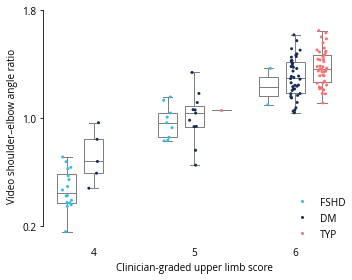

In [5]:
feat = 'brooke_max_sa_ea_ratio'

df = df_all[df_all.brooke_score >= 4].copy()
df['brooke_group'] = df.brooke_score.apply(lambda x : f'{int(x)}')

plt.figure(figsize=(5,4))
sns.boxplot(df, x='brooke_group', y=feat, hue='type', dodge=True, gap=0.3, width=0.8,
              hue_order=['FSHD', 'DM', 'TYP'], linewidth=1, whis=[0, 100],
              order=['4', '5', '6'],
              palette=['#808080']*3, saturation=1, fill=None,  legend=False)
np.random.seed(0)
sns.stripplot(df, x='brooke_group', y=feat, hue='type', dodge=True, size=3,
              hue_order=['FSHD', 'DM', 'TYP'], jitter=0.15,
              palette=[cp[3], cp[0], cp[1]], alpha=1)
plt.yticks([0.2, 1.0, 1.8])
plt.ylim(0.1, 1.8)
sns.despine(trim=True)
sns.despine(bottom=True, trim=False)
plt.gca().tick_params(bottom=False)
plt.ylabel('Video shoulder–elbow angle ratio')
plt.xlabel('Clinician-graded upper limb score')

plt.tight_layout()
plt.legend(loc='lower right', frameon=False, borderpad=0, borderaxespad=0)
plt.savefig(figdir/'fig3b_brooke_score.pdf')
plt.show()
